# Day 1: Natural Language Processing (NLP) Fundamentals and Statistical Language Models

This notebook covers the foundational concepts of NLP and traditional statistical methods that preceded modern Large Language Models (LLMs).

## 1. Setup and Imports

In [1]:
# Core libraries for NLP and data processing
import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK for traditional NLP tasks
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Scikit-learn for machine learning models
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ismetcansahin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ismetcansahin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ismetcansahin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ismetcansahin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## 2. Regular Expressions (Regex) for Text Pattern Matching

Regex is a powerful tool for finding patterns in text. It's the foundation of text processing.

In [2]:
# Sample text for demonstration
sample_text = """Contact us at support@example.com or sales@company.org.
Phone numbers: +1-555-123-4567, (555) 987-6543
Visit our website: https://www.example.com
Prices: $19.99, $299.00, €45.50"""

print("Original Text:")
print(sample_text)
print("\n" + "="*50 + "\n")

# Extract email addresses
emails = re.findall(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', sample_text)
print(f"Emails found: {emails}")

# Extract phone numbers
phones = re.findall(r'\+?\d[\d\s\-\(\)]{8,}\d', sample_text)
print(f"Phone numbers found: {phones}")

# Extract URLs
urls = re.findall(r'https?://[^\s]+', sample_text)
print(f"URLs found: {urls}")

# Extract prices
prices = re.findall(r'[$€]\d+\.\d{2}', sample_text)
print(f"Prices found: {prices}")

Original Text:
Contact us at support@example.com or sales@company.org.
Phone numbers: +1-555-123-4567, (555) 987-6543
Visit our website: https://www.example.com
Prices: $19.99, $299.00, €45.50


Emails found: ['support@example.com', 'sales@company.org']
Phone numbers found: ['+1-555-123-4567', '555) 987-6543']
URLs found: ['https://www.example.com']
Prices found: ['$19.99', '$299.00', '€45.50']


## 3. Text Tokenization

Tokenization is the process of breaking text into smaller units (tokens) like words or sentences.

In [4]:
import nltk
nltk.download('punkt_tab')

text = """Natural Language Processing (NLP) is a fascinating field. 
It combines linguistics, computer science, and artificial intelligence. 
Modern NLP systems can understand and generate human language!"""

# Sentence tokenization
sentences = sent_tokenize(text)
print("Sentence Tokenization:")
for i, sent in enumerate(sentences, 1):
    print(f"{i}. {sent}")

print("\n" + "="*50 + "\n")

# Word tokenization
words = word_tokenize(text)
print(f"Word Tokenization ({len(words)} tokens):")
print(words[:20])  # Show first 20 tokens

# Simple whitespace tokenization (basic approach)
simple_tokens = text.split()
print(f"\nSimple split ({len(simple_tokens)} tokens):")
print(simple_tokens[:15])

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ismetcansahin/nltk_data...


Sentence Tokenization:
1. Natural Language Processing (NLP) is a fascinating field.
2. It combines linguistics, computer science, and artificial intelligence.
3. Modern NLP systems can understand and generate human language!


Word Tokenization (32 tokens):
['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'is', 'a', 'fascinating', 'field', '.', 'It', 'combines', 'linguistics', ',', 'computer', 'science', ',', 'and', 'artificial']

Simple split (25 tokens):
['Natural', 'Language', 'Processing', '(NLP)', 'is', 'a', 'fascinating', 'field.', 'It', 'combines', 'linguistics,', 'computer', 'science,', 'and', 'artificial']


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 4. Stop Words Removal

Stop words are common words (like 'the', 'is', 'at') that often don't carry significant meaning for analysis.

In [5]:
# Get English stop words
stop_words = set(stopwords.words('english'))

print(f"Total stop words in NLTK: {len(stop_words)}")
print(f"Sample stop words: {list(stop_words)[:20]}")

# Example text
text = "The quick brown fox jumps over the lazy dog in the garden"
words = word_tokenize(text.lower())

# Remove stop words
filtered_words = [word for word in words if word not in stop_words and word.isalpha()]

print(f"\nOriginal: {words}")
print(f"After removing stop words: {filtered_words}")
print(f"Reduction: {len(words)} → {len(filtered_words)} tokens ({(1-len(filtered_words)/len(words))*100:.1f}% removed)")

Total stop words in NLTK: 198
Sample stop words: ['him', 'isn', "you'd", 'until', 'only', "i'm", 'am', 'haven', "needn't", 'theirs', 'did', 'out', 'doing', "shan't", 'up', 'ourselves', 'as', 'but', 'that', "isn't"]

Original: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'in', 'the', 'garden']
After removing stop words: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog', 'garden']
Reduction: 12 → 7 tokens (41.7% removed)


## 5. Stemming and Lemmatization

Both techniques reduce words to their base form, but lemmatization is more sophisticated.

In [6]:
# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Test words
words = ['running', 'runs', 'ran', 'easily', 'fairly', 'better', 'studies', 'studying']

print("Word\t\tStemming\tLemmatization")
print("="*50)
for word in words:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word, pos='v')  # 'v' for verb
    print(f"{word}\t\t{stemmed}\t\t{lemmatized}")

# Demonstrate on a sentence
sentence = "The striped bats are hanging on their feet for best"
words = word_tokenize(sentence)

stemmed_sentence = ' '.join([stemmer.stem(word) for word in words])
lemmatized_sentence = ' '.join([lemmatizer.lemmatize(word) for word in words])

print(f"\nOriginal: {sentence}")
print(f"Stemmed: {stemmed_sentence}")
print(f"Lemmatized: {lemmatized_sentence}")

Word		Stemming	Lemmatization
running		run		run
runs		run		run
ran		ran		run
easily		easili		easily
fairly		fairli		fairly
better		better		better
studies		studi		study
studying		studi		study

Original: The striped bats are hanging on their feet for best
Stemmed: the stripe bat are hang on their feet for best
Lemmatized: The striped bat are hanging on their foot for best


## 6. Bag of Words (BoW) Model

BoW represents text as a collection of words, ignoring grammar and word order.

Bag of Words Matrix:
       amazing  and  are  deep  is  learning  love  machine  related  too
Doc 1        0    0    0     0   0         1     1        1        0    0
Doc 2        1    0    0     0   1         1     0        1        0    0
Doc 3        0    0    0     1   0         1     1        0        0    1
Doc 4        0    1    1     1   0         2     0        1        1    0


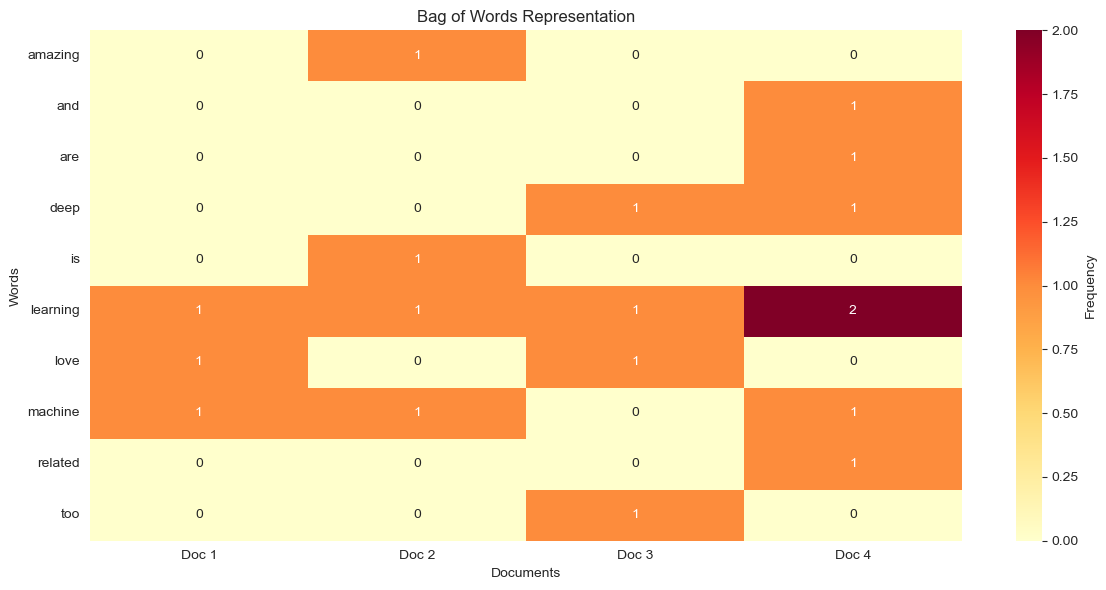

In [7]:
# Sample documents
documents = [
    "I love machine learning",
    "Machine learning is amazing",
    "I love deep learning too",
    "Deep learning and machine learning are related"
]

# Create Bag of Words using CountVectorizer
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)

# Get feature names (vocabulary)
feature_names = vectorizer.get_feature_names_out()

# Convert to DataFrame for better visualization
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=feature_names)
bow_df.index = [f"Doc {i+1}" for i in range(len(documents))]

print("Bag of Words Matrix:")
print(bow_df)

# Visualize
plt.figure(figsize=(12, 6))
sns.heatmap(bow_df.T, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
plt.title('Bag of Words Representation')
plt.xlabel('Documents')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

## 7. TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF weighs words by their importance: frequent in a document but rare across all documents.

TF-IDF Matrix:
       amazing    and    are   deep     is  learning   love  machine  related  \
Doc 1    0.000  0.000  0.000  0.000  0.000     0.457  0.691    0.560    0.000   
Doc 2    0.611  0.000  0.000  0.000  0.611     0.319  0.000    0.390    0.000   
Doc 3    0.000  0.000  0.000  0.497  0.000     0.329  0.497    0.000    0.000   
Doc 4    0.000  0.442  0.442  0.348  0.000     0.461  0.000    0.282    0.442   

         too  
Doc 1  0.000  
Doc 2  0.000  
Doc 3  0.631  
Doc 4  0.000  


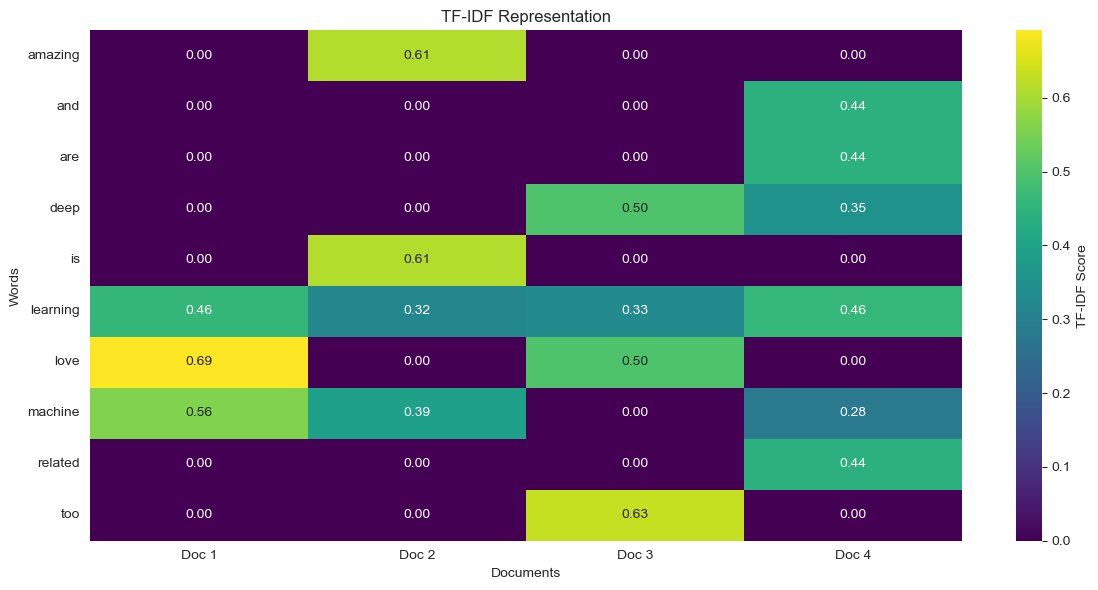


Comparison for word 'learning':
       BoW    TF-IDF
Doc 1    1  0.457453
Doc 2    1  0.318782
Doc 3    1  0.329023
Doc 4    2  0.461325


In [8]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(len(documents))]
)

print("TF-IDF Matrix:")
print(tfidf_df.round(3))

# Visualize
plt.figure(figsize=(12, 6))
sns.heatmap(tfidf_df.T, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'TF-IDF Score'})
plt.title('TF-IDF Representation')
plt.xlabel('Documents')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

# Compare BoW vs TF-IDF for a specific word
word = 'learning'
if word in bow_df.columns:
    print(f"\nComparison for word '{word}':")
    comparison_df = pd.DataFrame({
        'BoW': bow_df[word],
        'TF-IDF': tfidf_df[word]
    })
    print(comparison_df)

## 8. N-grams: Capturing Word Sequences

N-grams capture sequences of N consecutive words, preserving some context.

In [9]:
text = "Natural language processing enables computers to understand human language"

# Generate unigrams (1-gram)
unigram_vectorizer = CountVectorizer(ngram_range=(1, 1))
unigrams = unigram_vectorizer.fit_transform([text])
print("Unigrams (single words):")
print(unigram_vectorizer.get_feature_names_out())

# Generate bigrams (2-gram)
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigrams = bigram_vectorizer.fit_transform([text])
print("\nBigrams (word pairs):")
print(bigram_vectorizer.get_feature_names_out())

# Generate trigrams (3-gram)
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))
trigrams = trigram_vectorizer.fit_transform([text])
print("\nTrigrams (word triplets):")
print(trigram_vectorizer.get_feature_names_out())

# Combined: unigrams + bigrams
combined_vectorizer = CountVectorizer(ngram_range=(1, 2))
combined = combined_vectorizer.fit_transform([text])
print(f"\nCombined (1-2 grams): {len(combined_vectorizer.get_feature_names_out())} features")
print(combined_vectorizer.get_feature_names_out())

Unigrams (single words):
['computers' 'enables' 'human' 'language' 'natural' 'processing' 'to'
 'understand']

Bigrams (word pairs):
['computers to' 'enables computers' 'human language' 'language processing'
 'natural language' 'processing enables' 'to understand'
 'understand human']

Trigrams (word triplets):
['computers to understand' 'enables computers to'
 'language processing enables' 'natural language processing'
 'processing enables computers' 'to understand human'
 'understand human language']

Combined (1-2 grams): 16 features
['computers' 'computers to' 'enables' 'enables computers' 'human'
 'human language' 'language' 'language processing' 'natural'
 'natural language' 'processing' 'processing enables' 'to' 'to understand'
 'understand' 'understand human']


## 9. Naive Bayes Text Classification

A simple but effective probabilistic classifier for text data.

In [ ]:
# Sample dataset: sentiment classification
texts = [
    "I love this product, it's amazing",
    "This is the best purchase I've made",
    "Absolutely fantastic, highly recommend",
    "Great quality and fast shipping",
    "Terrible product, waste of money",
    "Very disappointed, poor quality",
    "Worst purchase ever, do not buy",
    "Horrible experience, not recommended",
    "Excellent service and product",
    "Perfect, exactly what I needed",
    "Bad quality, broke after one day",
    "Not worth the price, very poor"
]

labels = [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]  # 1=positive, 0=negative

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vec, y_train)

# Make predictions
y_pred = nb_classifier.predict(X_test_vec)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Test with new examples
new_texts = [
    "This product is wonderful",
    "I hate this, very bad"
]
new_vec = vectorizer.transform(new_texts)
predictions = nb_classifier.predict(new_vec)

print("\nPredictions on new texts:")
for text, pred in zip(new_texts, predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Text: '{text}' → {sentiment}")

## 10. Limitations of Traditional Methods

Understanding why we need modern approaches like transformers and LLMs.

In [ ]:
# Demonstrate limitations

print("=== LIMITATION 1: Loss of Word Order ===")
sent1 = "The dog bit the man"
sent2 = "The man bit the dog"

bow_vec = CountVectorizer()
bow_result = bow_vec.fit_transform([sent1, sent2])
bow_df = pd.DataFrame(bow_result.toarray(), columns=bow_vec.get_feature_names_out())
print(f"Sentence 1: {sent1}")
print(f"Sentence 2: {sent2}")
print("\nBoW representation (identical despite different meanings):")
print(bow_df)

print("\n=== LIMITATION 2: No Semantic Understanding ===")
sent3 = "The movie was not bad"
sent4 = "The movie was good"
print(f"Sentence 3: {sent3} (positive meaning)")
print(f"Sentence 4: {sent4} (positive meaning)")
print("Traditional methods struggle with negations and context.")

print("\n=== LIMITATION 3: Vocabulary Size ===")
large_vocab = ["word" + str(i) for i in range(10000)]
print(f"With 10,000 unique words, BoW creates a sparse matrix with 10,000 dimensions.")
print(f"Most values are zero (sparse), inefficient for computation.")

print("\n=== LIMITATION 4: No Context Understanding ===")
sent5 = "I went to the bank to deposit money"
sent6 = "I sat on the river bank"
print(f"Sentence 5: {sent5}")
print(f"Sentence 6: {sent6}")
print("The word 'bank' has different meanings, but traditional methods treat them identically.")

print("\n=== WHY WE NEED MODERN LLMs ===")
print("✓ Understand word order and grammar")
print("✓ Capture semantic meaning and context")
print("✓ Handle negations and complex language")
print("✓ Learn word relationships (embeddings)")
print("✓ Transfer learning across tasks")

## Summary

Today we covered:
1. **Regex**: Pattern matching in text
2. **Tokenization**: Breaking text into words/sentences
3. **Stop Words**: Removing common words
4. **Stemming/Lemmatization**: Reducing words to base forms
5. **Bag of Words**: Simple text representation
6. **TF-IDF**: Weighted word importance
7. **N-grams**: Capturing word sequences
8. **Naive Bayes**: Statistical classification
9. **Limitations**: Why we need modern LLMs

These traditional methods laid the foundation for modern NLP, but their limitations drove the development of neural networks and transformer-based models.